# Exakte Verfahrenswahrscheinlichkeit von Konfidenzintervallen

Für jedes $p$ wird die tatsächliche Verfahrenswahrscheinlichkeit

$$
\gamma_n(p)=P_p\bigl(p\in KI_\gamma(H)\bigr)
$$

unter dem Binomialmodell $X\sim B(n,p)$ berechnet. Zur Auswahl stehen das Wald-, das Wilson- und das Clopper–Pearson-Intervall.

Die Grafik zeigt $\gamma_n(p)-\gamma$. Die gestrichelte Nulllinie entspricht dem vorgegebenen Zielniveau. Bei $p=p_0$ markieren eine feine senkrechte Linie und ein Punkt die tatsächliche Verfahrenswahrscheinlichkeit.

> **Modellhinweis:** Die Rechnung ist exakt für das jeweils festgelegte Intervallverfahren unter dem Binomialmodell. *Exakt* bedeutet hier nicht, dass die tatsächliche Verfahrenswahrscheinlichkeit für jedes $p$ genau gleich $\gamma$ ist.

## Eingaben

Nur die folgende Zelle muss verändert werden.

- `procedure`: `"Wilson"`, `"Wald"` oder `"Clopper-Pearson"`
- `n`: Stichprobenumfang
- `gamma`: Zielniveau
- `p0`: markierter Modellparameter
- `save_figure`: `True` oder `False`

Die weiteren Eingaben steuern lediglich Ausschnitt, Beschriftung, Anzeige und Dateiausgabe.

In [9]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import beta, binom, norm


@dataclass(frozen=True)
class Config:
    # Mathematische Eingaben
    procedure: str = "Wilson"
    n: int = 400
    gamma: float = 0.90
    p0: float = 0.15

    # Dargestellter Bereich
    p_min: float = 0.02
    p_max: float = 0.98
    number_of_p_values: int = 1001

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True
    show_annotation: bool = True

    # Ausgabe des Notebooks
    decimals: int = 4
    show_text_output: bool = True
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung und mathematische Berechnung

Für jede mögliche Trefferzahl $x=0,\ldots,n$ wird zunächst das gewählte Konfidenzintervall bestimmt. Für einen festen Parameterwert $p$ werden anschließend die Binomialwahrscheinlichkeiten genau derjenigen Trefferzahlen addiert, deren Intervall $p$ enthält:

$$
\gamma_n(p)
=\sum_{x:\,p\in KI_\gamma(x/n)}
\binom{n}{x}p^x(1-p)^{n-x}.
$$

Dieselbe Berechnung wird für alle dargestellten Werte von $p$ wiederholt.

In [10]:
PROCEDURE_NAMES = {
    "wald": "Wald",
    "wilson": "Wilson",
    "clopper-pearson": "Clopper-Pearson",
    "clopper–pearson": "Clopper-Pearson",
    "clopper pearson": "Clopper-Pearson",
}


@dataclass(frozen=True)
class Calculation:
    procedure: str
    z: float
    x: np.ndarray
    interval_lower: np.ndarray
    interval_upper: np.ndarray
    p: np.ndarray
    coverage: np.ndarray
    deviation: np.ndarray
    accepted_x_at_p0: np.ndarray
    coverage_at_p0: float


def canonical_procedure(name: str) -> str:
    key = name.strip().lower()
    if key not in PROCEDURE_NAMES:
        choices = "Wald, Wilson oder Clopper-Pearson"
        raise ValueError(f"Unbekanntes Verfahren. Möglich sind: {choices}.")
    return PROCEDURE_NAMES[key]


def validate_config(cfg: Config) -> None:
    canonical_procedure(cfg.procedure)
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if not 0.0 <= cfg.p0 <= 1.0:
        raise ValueError("p0 muss zwischen 0 und 1 liegen.")
    if not 0.0 <= cfg.p_min < cfg.p_max <= 1.0:
        raise ValueError("Für den p-Bereich muss 0 <= p_min < p_max <= 1 gelten.")
    if not cfg.p_min <= cfg.p0 <= cfg.p_max:
        raise ValueError("p0 muss im dargestellten p-Bereich liegen.")
    if cfg.number_of_p_values < 101:
        raise ValueError("number_of_p_values muss mindestens 101 sein.")
    if not isinstance(cfg.decimals, int) or not 0 <= cfg.decimals <= 10:
        raise ValueError("decimals muss eine ganze Zahl zwischen 0 und 10 sein.")
    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def confidence_intervals(
    *,
    n: int,
    gamma: float,
    procedure: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    x = np.arange(n + 1)
    h = x / n
    alpha = 1.0 - gamma
    z = norm.ppf(1.0 - alpha / 2.0)

    if procedure == "Wald":
        half_width = z * np.sqrt(h * (1.0 - h) / n)
        lower = np.clip(h - half_width, 0.0, 1.0)
        upper = np.clip(h + half_width, 0.0, 1.0)

    elif procedure == "Wilson":
        denominator = 1.0 + z**2 / n
        center = (h + z**2 / (2.0 * n)) / denominator
        half_width = (
            z
            * np.sqrt(h * (1.0 - h) / n + z**2 / (4.0 * n**2))
            / denominator
        )
        lower = center - half_width
        upper = center + half_width

    else:  # Clopper-Pearson
        lower = np.zeros(n + 1)
        upper = np.ones(n + 1)
        lower[1:] = beta.ppf(alpha / 2.0, x[1:], n - x[1:] + 1)
        upper[:-1] = beta.ppf(1.0 - alpha / 2.0, x[:-1] + 1, n - x[:-1])

    return x, lower, upper, z


def coverage_probability(
    p: float,
    *,
    n: int,
    x: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
) -> tuple[float, np.ndarray]:
    included = (lower <= p) & (p <= upper)
    accepted_x = x[included]
    probability = float(binom.pmf(accepted_x, n, p).sum())
    return probability, accepted_x


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)
    procedure = canonical_procedure(cfg.procedure)
    x, lower, upper, z = confidence_intervals(
        n=cfg.n, gamma=cfg.gamma, procedure=procedure
    )

    p = np.linspace(cfg.p_min, cfg.p_max, cfg.number_of_p_values)
    coverage = np.empty_like(p)
    for index, parameter in enumerate(p):
        coverage[index], _ = coverage_probability(
            float(parameter),
            n=cfg.n,
            x=x,
            lower=lower,
            upper=upper,
        )

    coverage_at_p0, accepted_x_at_p0 = coverage_probability(
        cfg.p0, n=cfg.n, x=x, lower=lower, upper=upper
    )

    return Calculation(
        procedure=procedure,
        z=z,
        x=x,
        interval_lower=lower,
        interval_upper=upper,
        p=p,
        coverage=coverage,
        deviation=coverage - cfg.gamma,
        accepted_x_at_p0=accepted_x_at_p0,
        coverage_at_p0=coverage_at_p0,
    )

## Grafik

Die Grafik ist bewusst in Graustufen angelegt. Die Kurve zeigt ausschließlich das ausgewählte Verfahren; eine Legende ist daher nicht nötig. Titel, Untertitel und Beschriftung des markierten Punkts lassen sich unabhängig voneinander ein- und ausschalten.

In [11]:
def german_tick(value: float, _position: float) -> str:
    if abs(value) < 5e-12:
        value = 0.0
    return f"{value:g}".replace(".", ",")


def math_decimal(value: float, decimals: int) -> str:
    return f"{value:.{decimals}f}".replace(".", "{,}")


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(8.0, 4.8))

    ax.plot(
        calculation.p,
        calculation.deviation,
        color="0.35",
        linewidth=0.8, #1.35
        zorder=3,
    )
    ax.axhline(
        0.0,
        color="0.55",
        linestyle="--",
        linewidth=0.9,
        zorder=1,
    )
    ax.axvline(
        cfg.p0,
        color="0.65",
        linewidth=0.8,
        zorder=1,
    )

    deviation_at_p0 = calculation.coverage_at_p0 - cfg.gamma
    ax.scatter(
        [cfg.p0],
        [deviation_at_p0],
        s=20,
        facecolor="white",
        edgecolor="white",
        zorder=5,
    )
    ax.scatter(
        [cfg.p0],
        [deviation_at_p0],
        s=10,
        facecolor="gray",
        edgecolor="black",
        zorder=6,
    )

    if cfg.show_annotation:
        p0_text = math_decimal(cfg.p0, 2)
        coverage_text = math_decimal(calculation.coverage_at_p0, 3)
        ax.annotate(
            rf"$p_0={p0_text}:\;\gamma_{{{cfg.n}}}(p_0)\approx{coverage_text}$",
            xy=(cfg.p0, deviation_at_p0),
            xytext=(8, -30 if deviation_at_p0 <= 0 else 12),
            textcoords="offset points",
            ha="left",
            va="top" if deviation_at_p0 <= 0 else "bottom",
            fontsize=10.5,
            color="0.15",
        )

    y_min = min(float(calculation.deviation.min()), deviation_at_p0, 0.0)
    y_max = max(float(calculation.deviation.max()), deviation_at_p0, 0.0)
    padding = max(0.004, 0.10 * (y_max - y_min))
    ax.set_xlim(cfg.p_min, cfg.p_max)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.set_xlabel(r"$p$", fontsize=14)
    ax.set_ylabel(r"$\gamma_n(p)-\gamma$", fontsize=14, rotation=90, labelpad=10)
    ax.xaxis.set_major_formatter(FuncFormatter(german_tick))
    ax.yaxis.set_major_formatter(FuncFormatter(german_tick))
    ax.tick_params(labelsize=10.5)

    title = "Tatsächliche Verfahrenswahrscheinlichkeit"
    gamma_text = math_decimal(cfg.gamma, 2)
    subtitle = (
        rf"{calculation.procedure}-Verfahren, $n={cfg.n}$, "
        rf"Zielniveau $\gamma={gamma_text}$"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=15, pad=29)
        ax.text(
            0.5,
            1.025,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=10.5,
            color="0.2",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=15, pad=14)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=10.5, color="0.2", pad=14)

    fig.tight_layout()
    return fig, ax

## Ausgabe

Berechnung, Grafik, Anzeige und Speicherung bleiben getrennt. Ist `save_figure = True`, wird der Unterordner `fig/` bei Bedarf automatisch angelegt. PNG und PDF erhalten einen aus Verfahren, $n$, $\gamma$ und $p_0$ gebildeten Dateinamen.

Für die Standardeinstellungen entstehen beispielsweise

- `Verfahrenswahrscheinlichkeit-Wilson-n400-gamma09-p015.png`,
- `Verfahrenswahrscheinlichkeit-Wilson-n400-gamma09-p015.pdf`.

Verfahren: Wilson
Binomialmodell: X ~ B(400, 0.15)
Zielniveau gamma = 0.9000
Bei p0 = 0.15 enthält das Intervall p0 genau für: 49 <= X <= 71
gamma_400(0.15) = P_0.15(49 <= X <= 71) = 0.8932
Abweichung vom Zielniveau: -0.0068
Gespeichert: fig/Verfahrenswahrscheinlichkeit-Wilson-n400-gamma09-p015.png
Gespeichert: fig/Verfahrenswahrscheinlichkeit-Wilson-n400-gamma09-p015.pdf


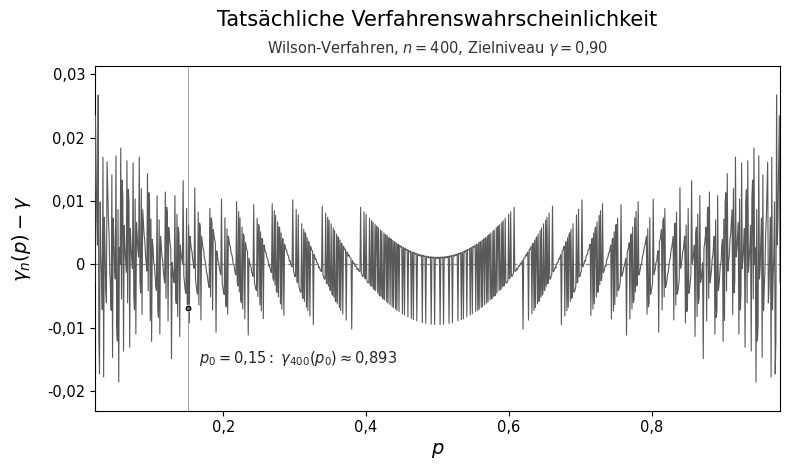

In [12]:
def number_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    return text.replace("-", "m").replace(".", "")


def figure_stem(cfg: Config, calculation: Calculation) -> str:
    gamma = number_token(cfg.gamma)
    p0 = number_token(cfg.p0)
    return (
        f"Verfahrenswahrscheinlichkeit-{calculation.procedure}-"
        f"n{cfg.n}-gamma{gamma}-p{p0}"
    )


def save_figure(
    fig: plt.Figure,
    cfg: Config,
    calculation: Calculation,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg, calculation)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def format_integer_ranges(values: np.ndarray) -> str:
    if values.size == 0:
        return "keine Trefferzahl"

    starts = [int(values[0])]
    ends: list[int] = []
    for previous, current in zip(values[:-1], values[1:]):
        if int(current) != int(previous) + 1:
            ends.append(int(previous))
            starts.append(int(current))
    ends.append(int(values[-1]))

    parts = []
    for start, end in zip(starts, ends):
        if start == end:
            parts.append(f"X = {start}")
        else:
            parts.append(f"{start} <= X <= {end}")
    return " oder ".join(parts)


def print_results(
    cfg: Config,
    calculation: Calculation,
    saved_files: tuple[Path, ...],
) -> None:
    accepted = format_integer_ranges(calculation.accepted_x_at_p0)
    print(f"Verfahren: {calculation.procedure}")
    print(f"Binomialmodell: X ~ B({cfg.n}, {cfg.p0:g})")
    print(f"Zielniveau gamma = {cfg.gamma:.{cfg.decimals}f}")
    print(f"Bei p0 = {cfg.p0:g} enthält das Intervall p0 genau für: {accepted}")
    print(
        f"gamma_{cfg.n}({cfg.p0:g}) = P_{cfg.p0:g}({accepted}) = "
        f"{calculation.coverage_at_p0:.{cfg.decimals}f}"
    )
    print(
        f"Abweichung vom Zielniveau: "
        f"{calculation.coverage_at_p0 - cfg.gamma:+.{cfg.decimals}f}"
    )
    for output_path in saved_files:
        print(f"Gespeichert: {output_path}")


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg, calculation)

    if cfg.show_text_output:
        print_results(cfg, calculation, saved_files)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)